# Tikhonov Regularization
Here, we use Tikhonov regularization to compute $\langle r^2 \rangle$ of the back-rotated resonance.

## Background: Explicit Back-rotation
$\langle r^2\rangle_\phi$ is radius squared operator of CS'd state $\psi_\phi$. $r\rightarrow e^{i\phi} r$, so
$$
    \Psi_\theta(r) = U_\theta \Psi(r) = e^{3i\theta/2}\Psi(re^{i\theta})
$$
$$
    = e^{i\theta/2}\frac{u(re^{i\theta})}{r}Y^0_0.
$$
The $e^{3i\theta/2}$ factor comes from requiring that the complex scaling operator is unitary in 3D.
$$
\langle r^2_\theta \rangle =\frac{1}{4}\frac{(\Psi_\theta|r^2_\theta|\Psi_\theta)}{(\Psi_\theta|\Psi_\theta)}
$$
$$
    =\frac{1}{4}\frac{e^{i\theta}\int \;d\Omega\; (Y_0^0(\Omega))^2 \int\; dr \; r^2e^{2i\theta} u_\theta(r)^2}{e^{i\theta}\int \;d\Omega\; (Y^0_0(\Omega))^2\int\;dr \; u_\theta(r)^2} = \frac{e^{2i\theta}}{4} \int\;dr\; r^2 u_\theta(r)^2
$$

the $1/4$ factor is just to average out the CM. $\Gamma$ factor is angular contribution (we work exclusively in S wave) and is ignored (though here it cancels out anyway). DVR code is working in relative coordinate of reduced radial equation, so $u_\phi$ are the eigenvectors.

In DVR quadrature:
$$
 \langle r^2_\theta\rangle = e^{2i\theta}\frac{1}{4}\sum_k r_k^2 u_\theta(r_k)^2 \omega_k = e^{2i\theta} \frac{1}{4} \sum_k c_k^2 r_k^2,
$$
where $c_k=u_\theta(r_k)\sqrt{\omega_k}$ is the $k$-th DVR expansion coefficient, and the quadrature weights $\omega_k$ cancel due to c-normalization.

$\langle r^2 \rangle_{\text{BR}}$ is the expectation value of the back-rotated Gamow state. Here $r^2$ is un-rotated, and $\Psi_{\theta=0}=U_\theta^{-1}\Psi_{\theta}=e^{-3i\theta/2}\Psi_{\theta}(re^{-i\phi}) =\frac{u_\theta(e^{-i\theta} r)}{r}Y^0_0$. Thus,

$$
\langle r^2 \rangle_{\text{BR}} = \frac{1}{4}\frac{\int \;d\Omega\;(Y_0^0(\Omega))^2\int dr\;r^2 u_\phi^2 (e^{-i\phi}r)}{\int\;d\Omega\;(Y_0^0(\Omega))^2\int dr\;u_\phi^2 (e^{-i\phi}r)} = \frac{1}{4} \frac{\int dr\;r^2 u_\phi^2 (e^{-i\phi}r)}{\int dr\;u_\phi^2 (e^{-i\phi}r)}
$$
$$
=\frac{1}{4}\frac{e^{i3\theta}\lim_{\epsilon\rightarrow \infty}\int_0^{\epsilon e^{-i\theta}}\;dr'\;r'^2 u_\phi(r')^2}{e^{i\theta}\lim_{\epsilon\rightarrow \infty}\int_0^{\epsilon e^{-i\theta}}\;dr'\;u_\phi(r')^2}= \frac{e^{2i\theta}}{4}\frac{\lim_{\epsilon\rightarrow \infty}\int_0^{\epsilon e^{-i\theta}}\;dr'\;r'^2 u_\phi(r')^2}{\lim_{\epsilon\rightarrow \infty}\int_0^{\epsilon e^{-i\theta}}\;dr'\;u_\phi(r')^2},
$$

where $u_\phi(re^{-i\theta}) = u(r)$ is the original Gamow state, and $r'=re^{-i\theta}$. The integral bounds for this new variable are $r'$ $\rightarrow 0$ to $r'\rightarrow\infty$, but, formally, the integral is to be taken along the ray along $e^{-i\theta}$, so $r'\rightarrow 0$ to $r'\rightarrow \infty e^{-i\theta}$. Thus, the ratio above is formally $\infty/\infty$, but it is well-defined as the boundary value $\theta\rightarrow0$ of 
$$
    f(\theta)=\frac{e^{2i\theta}\int^\infty_0\;dr\;u_\theta(r)^2r^2}{4\int_0^\infty\;dr\; u_\theta(r)^2}
$$
which is constant in the "good" $\theta$ sector by the ABC theorem. I.e., this singularity in the function $\langle r^2_\theta\rangle(\theta)$, while not formally defined, approaches a finite limit. Formally, this ratio is only defined in the analytic continuation of this expectation value. Since the ratio is the same constant through the wedge, the analytic continuation to $\theta=0$ will be the same constant by the identity theorem.

In DVR quadrature,
$$
\langle r^2 \rangle_{\text{BR}} = \frac{1}{4}\frac{\sum_k r_k^2 u_\phi^2 (e^{-i\phi}r_k) \omega_k}{\sum_k u_\theta(e^{-i\theta}r_k)^2\omega_k}.
$$
We normalize the states wrt the DVR basis, so the denominator is 1. The back-rotated radius computed in this way is ill-posed as errors accumulate due to back-rotating the decaying state back to the divergent Gamow state.

In [1]:
from src.dvr import *
import matplotlib.pyplot as plt

In [ ]:
save_plots = True
plots_folder = Path("./plots/tikhonov_regtest")
plots_folder.mkdir(exist_ok=True, parents=True)

In [2]:
# define system parameters
n = 256                      # number of DVR grid points
phi = pi / 24                # rotation angle
real_res = 1.606 - 1j*0.047  # expected value of resonance
L = 50.0                     # system size

gauss_s = lambda r: 2.0 * exp(-((r-3.0)/1.5)**2) # potential

In [3]:
x_plot = np.linspace(0.0, L, 500)

### Compute the energy and $\langle r^2\rangle$ of the complex-scaled resonance at $\phi=\pi/24$.

In [4]:
# resonance wavefunction at phi=pi/24
test_system = DVR(n, L, rotation_angle=phi, potential=gauss_s)
eigval, eigstate = test_system.closest_to_resonance(real_res)
eigstate = eigstate / sqrt(np.sum(eigstate**2)) # c-normalizing just in case
rr = test_system.compute_rr(eigstate[:, 0], rotate_rr=True, regulator=False)
eigval = eigval[0]

resonance = test_system.DVR_to_position_space(eigstate[:, 0], x_plot)

print(f"Energy and radius of resonance at phi={phi:.3f}.")
print(f"\tE = {np.real(eigval):.3f} + j{np.imag(eigval):.3f}")
print(f"\t<r^2> = {np.real(rr):.3f} + j{np.imag(rr):.3f}")

Energy and radius of resonance at phi=0.131.
	E = 1.606 + j-0.047
	<r^2> = 0.774 + j0.200


### Attempt to explicitly back-rotate the complex-scaled resonance.
This gives us a bogus result

In [5]:
# explicit back-rotation
x_plot_br = exp(-1j * phi) * x_plot
resonance_br = test_system.DVR_to_position_space(eigstate[:, 0], x_plot_br)

# explicit back-rotation to compute <r^2>
rs, w = test_system.r, test_system.w
resonance_br_DVR = test_system.DVR_to_position_space(eigstate[:, 0], rs*exp(-1j*phi))
rr = 0.25 * exp(2j*phi) * w * np.sum(rs**2 * resonance_br_DVR**2)
print(f"Radius of back-rotated resonance is {np.real(rr):.3e} + 1j {np.imag(rr):.2e}.")

Radius of back-rotated resonance is -9.615e+71 + 1j -1.30e+71.


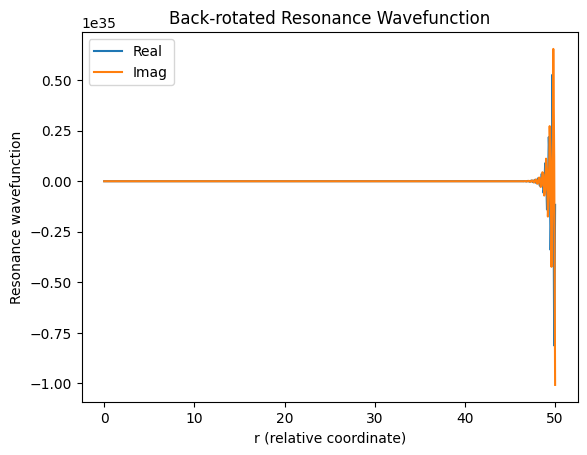

In [6]:
fig, ax = plt.subplots()
ax.plot(x_plot, np.real(resonance_br), label='Real')
ax.plot(x_plot, np.imag(resonance_br), label='Imag')
ax.set_xlabel("r (relative coordinate)")
ax.set_ylabel("Resonance wavefunction")
ax.set_title(r"Back-rotated Resonance Wavefunction")
ax.legend()
if save_plots:
    plt.savefig(plots_folder / "br_resonance_wavefunc_nocs.png")
plt.show()

## Tikhonov Regularization

$$
\langle r^2 \rangle_{\text{BR}} = \int dr\; r^2 u^2_\theta(e^{-i\theta}r)e^{2i\theta}
$$
Let $f_\theta(r) = r^2 u^2_\theta(r)$. Then, 
$$
\langle r^2 \rangle_{\text{BR}} = e^{4i\theta}\int dr\; f_\theta(e^{-i\theta} r).
$$
Changing variables $x=-\ln(r/r_0)$ gives $\tilde{f}_\theta(x)=f_\theta(r_0e^{-x})$ (domain goes from $(0, \infty)\rightarrow (-\infty,\infty)$. Fourier transform:
$$
\hat{f}_\theta(\xi) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^\infty dx\; e^{-ix\xi}\tilde{f}_\theta(x)
$$
Now, analytically continuing to complex plane: $\tilde{f}_\theta(x+iy)=f_\theta(r_0e^{-x}e^{-iy})$. So, $\tilde{f}_\theta(x+i\theta) = f_\theta(e^{-i\theta}r)$.
$$
\tilde{f}_\theta(x + i\theta) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^\infty d\xi\; e^{i(x+i\theta)\xi}\hat{f}_\theta(\xi)
$$
$$
    = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^\infty d\xi\; e^{ix\xi}e^{-\theta\xi}\hat{f}_\theta(\xi).
$$
Tikhonov cuts off the UV modes: $\Gamma_{\text{Tikhonov}} = \frac{1}{1+\kappa e^{-2\theta\xi}}$. Thus,
$$
\tilde{f}_{\text{reg},\theta}(x + i\theta)=  \frac{1}{\sqrt{2\pi}} \int_{-\infty}^\infty d\xi\; e^{ix\xi}e^{-\theta\xi}\hat{f}_\theta(\xi)\Gamma_{\text{Tikhonov}}.
$$

Thus,
$$
\langle r^2\rangle_{\text{BR}} = e^{4i\theta} \int_0^\infty dr \;\tilde{f}_{\text{reg},\theta}(r) = e^{4i\theta}\int_\infty^{-\infty}-r_0e^{-x}\;dx\;\tilde{f}_{\text{reg},\theta}(x+i\theta)
$$
$$
= e^{4i\theta}\int_{-\infty}^{\infty}r_0e^{-x}\;dx\;\tilde{f}_{\text{reg},\theta}(x+i\theta)
$$

Here, we use Tikhonov regularization to compute $\langle r^2\rangle$ of the back-rotated resonance.

In [7]:
# compute numerical FFTre

# compute log mesh
r0 = 1.0 # reference scale
xmin = -np.log(L / r0)
xmax = 50
N = 512
x = np.linspace(xmin, xmax, N)
r_log = r0 * exp(-x)

# compute wavefunction evaluated on log mesh
u_on_logmesh = test_system.DVR_to_position_space(eigstate[:, 0], r_log)
f = (r_log)**2 * (u_on_logmesh)**2

# compute FFT
# np.fft gives discrete FFT. Need Delta x / sqrt(2pi)
# to approx integral
f_hat = np.fft.fft(f) * (x[1] - x[0]) / sqrt(2*pi)
xi = np.fft.fftfreq(N, d=(x[1]-x[0])) * 2*pi

# apply tikhonov filter 
kappa = 4e-5
tikhonov = 1.0 / (1.0 + kappa * exp(-2*phi*xi))
f_reg = np.fft.ifft(f_hat * tikhonov * exp(-phi*xi)) * N * (xi[1] - xi[0]) / sqrt(2*pi)

# compute r^2.
rr = 0.25 * exp(4j*phi) * np.sum(f_reg * r_log) * (x[1] - x[0])
print(f"Radius of Tikhonov back-rotated wavefunc: r^2 = {np.real(rr):.3f} + 1j {np.imag(rr):.3f}.")

Radius of Tikhonov back-rotated wavefunc: r^2 = 0.789 + 1j 0.639.


### Sweep over the Tikhonov parameter to find a plateau
Tikhonov relies on a parameter $\kappa$ that is somewhat ad hoc (which is one of the reasons we're testing if EC can do it better). Unlike Zeldovich regularization, in which the result is exact in the limit $\lim_{\epsilon\rightarrow 0^+}$ (we only need to sweep through the Zeldovich parameter $\epsilon$ computationally because, at one point, it becomes small enough that numerical errors build up, so we can't take it to zero exactly: we have to decrease it until the regulator is able to tame the divergence but before numerical errors build up), Tikhonov regularization relies on a smoothing parameter that is somewhat arbitrary. There is no formal justification for it to take any one value. We have to sweep through and search for a plateau.

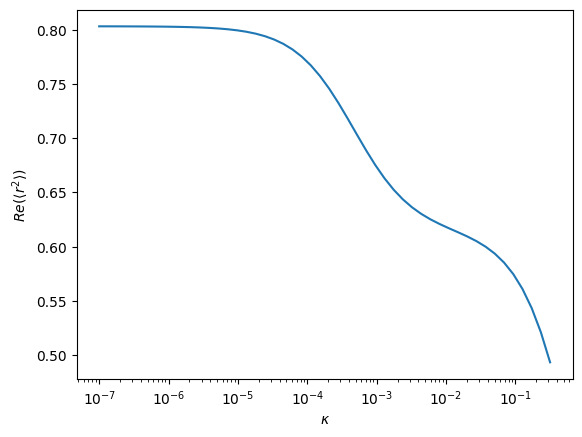

In [8]:
# sweep over Tikhonov parameter
kappas = np.logspace(-7, -0.5, 50)
rrs = []
for kappa in kappas:
    tikhonov = 1.0 / (1.0 + kappa * exp(-2*phi*xi))
    f_reg = np.fft.ifft(f_hat * tikhonov * exp(-phi*xi)) * N * (xi[1] - xi[0]) / sqrt(2*pi)

    # compute r^2.
    rr = 0.25 * exp(4j*phi) * np.sum(f_reg * r_log) * (x[1] - x[0])
    rrs.append(rr)

plt.semilogx(kappas, np.real(rrs))
plt.xlabel(r'$\kappa$')
plt.ylabel(r'$Re(\langle r^2\rangle)$')
plt.show()